# 🛡️ RxChat — Safety & Risk Classifier
### Person 2 — AraBERT Fine-tuning
**المطلوب:** نموذج يصنف الاستعلامات الطبية إلى Low / Medium / High Risk

---
**الخطوات:**
1. تثبيت المكتبات
2. تحميل البيانات
3. تحميل AraBERT
4. تدريب النموذج
5. تقييم النموذج
6. حفظ النموذج
7. بناء FastAPI endpoint

## 📦 الخطوة 1 — تثبيت المكتبات

In [ ]:
!pip install transformers datasets scikit-learn torch pandas numpy -q

^C



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 📂 الخطوة 2 — تحميل البيانات

In [1]:
import pandas as pd
import ast
import json

# ===========================================
# الطريقة الأضمن لقراءة الملف ده تحديداً
# ===========================================

# 1. نقرأ الملف كله كنص ونعالج الـ JSON يدوياً
data = []

with open('arabert_new.csv', 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        
        # نستخدم طريقة ذكية: نبدل أول 6 فواصل بس، والباقي نتعامل معه كحقول
        # لكن الأسهل: نستخدم csv.reader مع quotechar
        pass

# 2. الطريقة الأسهل والأضمن - نقرأ ببساطة كده:
try:
    df = pd.read_csv('arabert_new.csv', 
                     encoding='utf-8',
                     engine='python')  # engine='python' بيحل مشكلة الـ JSON
    
    print(f"✅ تمت القراءة بنجاح!")
    print(f"الشكل: {df.shape}")
    print(f"\nالأعمدة: {list(df.columns)}")
    print(f"\nأول صف:\n{df.iloc[0]}")
    
except Exception as e:
    print(f"الخطأ: {e}")
    
    # لو فشلت، نجرب الطريقة اليدوية:
    print("\n=== المحاولة اليدوية ===")
    
    with open('arabert_new.csv', 'r', encoding='utf-8') as f:
        lines = f.readlines()
    
    # أول سطر هو header
    header = lines[0].strip().split(',')
    
    rows = []
    for line_num, line in enumerate(lines[1:], start=2):
        # نعالج الخط بطريقة تحافظ على الـ JSON
        # نبحث عن آخر { ونعرف أن كل حاجة بعدها هي JSON حتى آخر }
        parts = line.strip().split(',')
        
        # الطريقة الأسهل: أول 5 أعمدة عادية، والعمود السادس هو الـ JSON، والباقي أعمدة عادية
        if len(parts) >= 6:
            row = []
            # الأعمدة الخمسة الأولى
            row.extend(parts[:5])
            
            # نجمع الأجزاء من 5 لحد ما نلاقي القوس اللي يقفل الـ JSON
            json_parts = []
            brace_count = 0
            for i, part in enumerate(parts[5:]):
                json_parts.append(part)
                brace_count += part.count('{') - part.count('}')
                if brace_count == 0 and part.strip().endswith('}'):
                    # يبقى الـ JSON خلص
                    remaining_parts = parts[5+i+1:] if i+1 < len(parts[5:]) else []
                    break
            else:
                remaining_parts = []
            
            row.append(','.join(json_parts))
            row.extend(remaining_parts)
            
            # نتأكد إن عدد الأعمدة مطابق للهيدر
            if len(row) > len(header):
                row = row[:len(header)]
            elif len(row) < len(header):
                row.extend([''] * (len(header) - len(row)))
            
            rows.append(row)
    
    df = pd.DataFrame(rows, columns=header[:len(rows[0])] if rows else header)
    print(f"✅ تمت القراءة بالطريقة اليدوية! الشكل: {df.shape}")

# عرض النتيجة
print(f"\n📊 أول 3 صفوف:")
df.head(3)

الخطأ: ',' expected after '"'

=== المحاولة اليدوية ===
✅ تمت القراءة بالطريقة اليدوية! الشكل: (2250, 13)

📊 أول 3 صفوف:


,id,drug_name,generic_name,drug_class,text,patient_context,risk_level,risk_flags,explanation,source,dialect_label,severity_score,doctor_referral
0,SYN000001,بنادول,Paracetamol,analgesic,"""دكتور، أنا خدت بنادول إكسترا ٣ حبات ورا بعض ع...","{""age"":30,""weight"":80,""conditions"":[],""current...",Low,[],"""سؤال عادي عن الجرعة القصوى المسموحة، بدون أعر...",patient_info_leaflet,egyptian_arabic,0.15,false
1,SYN000002,بروفين,Ibuprofen,nsaid,"""عندي آلام دوره، بنتي عمرها ١٤ سنه، بتاخد بروف...","{""age"":14,""weight"":50,""conditions"":[""dysmenorr...",Medium,[monitoring_required],"""ألم معدة من الأعراض الجانبية الشائعة للبروفين...",patient_info_leaflet,egyptian_arabic,0.42,false
2,SYN000003,كونكور,Bisoprolol,beta blocker,"""والدي لسه باديء كونكور من ٣ ايام، النهارده ضغ...","{""age"":70,""weight"":85,""conditions"":[""hypertens...",Medium,[monitoring_required],"""انخفاض الضغط والدوخة من الأعراض المتوقعة لبدا...",medical_guidelines,egyptian_arabic,0.35,false


In [2]:
import pandas as pd


print('شكل البيانات:', df.shape)
print('\nأول 5 صفوف:')
print(df.head())
print('\nتوزيع التصنيفات:')
print(df['risk_level'].value_counts())

شكل البيانات: (2250, 13)

أول 5 صفوف:
          id drug_name  generic_name      drug_class  \
0  SYN000001    بنادول   Paracetamol       analgesic   
1  SYN000002    بروفين     Ibuprofen           nsaid   
2  SYN000003    كونكور    Bisoprolol    beta blocker   
3  SYN000004   كريستور  Rosuvastatin          statin   
4  SYN000005    زاناكس    Alprazolam  benzodiazepine   

                                                text  \
0  "دكتور، أنا خدت بنادول إكسترا ٣ حبات ورا بعض ع...   
1  "عندي آلام دوره، بنتي عمرها ١٤ سنه، بتاخد بروف...   
2  "والدي لسه باديء كونكور من ٣ ايام، النهارده ضغ...   
3  "أنا خدت كريستور ٤٠ مجم امبارح بالليل، وحاسس ب...   
4  "والدتي عندها ٧٥ سنه، بتاخد ربع حبة زاناكس ٠.٢...   

                                     patient_context risk_level  \
0  {"age":30,"weight":80,"conditions":[],"current...        Low   
1  {"age":14,"weight":50,"conditions":["dysmenorr...     Medium   
2  {"age":70,"weight":85,"conditions":["hypertens...     Medium   
3  {"age":55,"weight

In [3]:
df = df[df['risk_level'].astype(str).str.strip() != '']

In [4]:
df.isna().sum()

id                 0
drug_name          0
generic_name       0
drug_class         0
text               0
patient_context    0
risk_level         0
risk_flags         0
explanation        0
source             0
dialect_label      0
severity_score     0
doctor_referral    0
dtype: int64

In [5]:
# ====================================================
# ✅ Fix labels + Balance data + Split correctly
# ====================================================

from sklearn.model_selection import train_test_split
from sklearn.utils import resample
import pandas as pd

# 1) تنظيف البيانات
df = df.copy()

df["text"] = df["text"].astype(str).str.strip()
df["text"] = df["text"].str.replace('"', '', regex=False)

df["risk_level"] = df["risk_level"].astype(str).str.strip()

# نخلي بس الليبلز الصحيحة
df = df[df["risk_level"].isin(["Low", "Medium", "High"])].reset_index(drop=True)

# 2) تعريف الليبلز قبل أي استخدام
label2id = {"Low": 0, "Medium": 1, "High": 2}
id2label = {0: "Low", 1: "Medium", 2: "High"}

df["label_id"] = df["risk_level"].map(label2id)

print("Original distribution:")
print(df["risk_level"].value_counts())

# 3) Balance data
df_low = df[df["risk_level"] == "Low"]
df_medium = df[df["risk_level"] == "Medium"]
df_high = df[df["risk_level"] == "High"]

# نخلي كل الكلاسات قد أكبر كلاس
max_count = max(len(df_low), len(df_medium), len(df_high))

df_low_balanced = resample(
    df_low,
    replace=True,
    n_samples=max_count,
    random_state=42
)

df_medium_balanced = resample(
    df_medium,
    replace=True,
    n_samples=max_count,
    random_state=42
)

df_high_balanced = resample(
    df_high,
    replace=True,
    n_samples=max_count,
    random_state=42
)

df_balanced = pd.concat(
    [df_low_balanced, df_medium_balanced, df_high_balanced],
    ignore_index=True
)

df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

# نأكد إن label_id موجود صح بعد الـ balance
df_balanced["label_id"] = df_balanced["risk_level"].map(label2id)

print("\nBalanced distribution:")
print(df_balanced["risk_level"].value_counts())

print("\nLabel mapping check:")
print(df_balanced[["risk_level", "label_id"]].drop_duplicates().sort_values("label_id"))

# 4) Split
train_df, test_df = train_test_split(
    df_balanced,
    test_size=0.2,
    random_state=42,
    stratify=df_balanced["label_id"]
)

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("\nTrain distribution:")
print(train_df["risk_level"].value_counts())

print("\nTest distribution:")
print(test_df["risk_level"].value_counts())

print("\n✅ Split done")
print("Train size:", len(train_df))
print("Test size:", len(test_df))

Original distribution:
risk_level
High      885
Low       675
Medium    614
Name: count, dtype: int64

Balanced distribution:
risk_level
Low       885
Medium    885
High      885
Name: count, dtype: int64

Label mapping check:
  risk_level  label_id
0        Low         0
2     Medium         1
6       High         2

Train distribution:
risk_level
High      708
Medium    708
Low       708
Name: count, dtype: int64

Test distribution:
risk_level
High      177
Low       177
Medium    177
Name: count, dtype: int64

✅ Split done
Train size: 2124
Test size: 531


## 🤖 الخطوة 3 — تحميل AraBERT

In [8]:
# ====================================================
# ✅ Load AraBERT Fresh Model
# ====================================================

from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

print("✅ Checking labels:")
print("label2id:", label2id)
print("id2label:", id2label)

MODEL_NAME = "aubmindlab/bert-base-arabertv2"

print("\n⏳ Loading AraBERT tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("⏳ Loading AraBERT model...")
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)

device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)

print("\n✅ AraBERT loaded successfully")
print("Device:", device)
print("num_labels:", model.config.num_labels)
print("id2label:", model.config.id2label)
print("label2id:", model.config.label2id)

✅ Checking labels:
label2id: {'Low': 0, 'Medium': 1, 'High': 2}
id2label: {0: 'Low', 1: 'Medium', 2: 'High'}

⏳ Loading AraBERT tokenizer...


c:\Users\mohma\AppData\Local\Programs\Python\Python310\lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


⏳ Loading AraBERT model...


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at aubmindlab/bert-base-arabertv2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



✅ AraBERT loaded successfully
Device: cpu
num_labels: 3
id2label: {0: 'Low', 1: 'Medium', 2: 'High'}
label2id: {'Low': 0, 'Medium': 1, 'High': 2}


## 🏋️ الخطوة 4 — تدريب النموذج

In [12]:
# ====================================================
# ✅ Prepare Dataset for Trainer
# ====================================================

from torch.utils.data import Dataset
import torch

MAX_LEN = 128

class SafetyDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=256):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = int(self.labels[idx])

        encoding = self.tokenizer(
            text,
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )

        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels": torch.tensor(label, dtype=torch.long)
        }


train_dataset = SafetyDataset(
    texts=train_df["text"].tolist(),
    labels=train_df["label_id"].tolist(),
    tokenizer=tokenizer,
    max_len=MAX_LEN
)

test_dataset = SafetyDataset(
    texts=test_df["text"].tolist(),
    labels=test_df["label_id"].tolist(),
    tokenizer=tokenizer,
    max_len=MAX_LEN
)

print("✅ Dataset ready")
print("Train samples:", len(train_dataset))
print("Test samples:", len(test_dataset))

# Test one sample
sample = train_dataset[0]
print("\nSample keys:", sample.keys())
print("input_ids shape:", sample["input_ids"].shape)
print("attention_mask shape:", sample["attention_mask"].shape)
print("label:", sample["labels"])

✅ Dataset ready
Train samples: 2124
Test samples: 531

Sample keys: dict_keys(['input_ids', 'attention_mask', 'labels'])
input_ids shape: torch.Size([128])
attention_mask shape: torch.Size([128])
label: tensor(2)


In [13]:
print(train_df['risk_level'].value_counts())
print(test_df['risk_level'].value_counts())

risk_level
High      708
Medium    708
Low       708
Name: count, dtype: int64
risk_level
High      177
Low       177
Medium    177
Name: count, dtype: int64


In [15]:
# ====================================================
# 🏋️ Train AraBERT Safety Model
# ====================================================

import numpy as np
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from transformers import TrainingArguments, Trainer, EarlyStoppingCallback

# Metrics
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    return {
        "accuracy": accuracy_score(labels, preds),
        "macro_f1": f1_score(labels, preds, average="macro"),
        "weighted_f1": f1_score(labels, preds, average="weighted")
    }


training_args = TrainingArguments(
    output_dir="./safety_model_fixed",

    num_train_epochs=3,

    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,

    learning_rate=2e-5,
    warmup_ratio=0.1,
    weight_decay=0.01,

    evaluation_strategy="epoch",
    save_strategy="epoch",

    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,

    logging_steps=50,
    save_total_limit=1,
    report_to="none",

    dataloader_num_workers=0,
    disable_tqdm=False
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

print("🚀 Training started...")
trainer.train()
print("✅ Training finished")

  0%|          | 6/1330 [01:50<6:46:22, 18.42s/it]


🚀 Training started...


                                                
  6%|▋         | 50/798 [02:04<28:33,  2.29s/it]

{'loss': 1.1033, 'grad_norm': 8.620506286621094, 'learning_rate': 1.25e-05, 'epoch': 0.19}


                                                 
 13%|█▎        | 100/798 [04:09<26:01,  2.24s/it]

...

{'loss': 0.3534, 'grad_norm': 25.97209358215332, 'learning_rate': 1.3370473537604459e-06, 'epoch': 2.82}


100%|██████████| 798/798 [33:22<00:00,  2.04s/it]

































                                                 
                                     

100%|██████████| 798/798 [34:05<00:00,  2.04s/it]



{'eval_loss': 0.5575544238090515, 'eval_accuracy': 0.7947269303201506, 'eval_macro_f1': 0.7950745317810674, 'eval_weighted_f1': 0.7950745317810675, 'eval_runtime': 40.4779, 'eval_samples_per_second': 13.118, 'eval_steps_per_second': 0.84, 'epoch': 3.0}


                                                 
100%|██████████| 798/798 [34:49<00:00,  2.62s/it]


{'train_runtime': 2089.6595, 'train_samples_per_second': 3.049, 'train_steps_per_second': 0.382, 'train_loss': 0.5870369239558552, 'epoch': 3.0}
✅ Training finished


## 📊 الخطوة 5 — تقييم النموذج

In [ ]:
print(train_df['label_id'].value_counts())
print(train_df['risk_level'].value_counts())

label_id
2    708
1    708
0    708
Name: count, dtype: int64
risk_level
High      708
Medium    708
Low       708
Name: count, dtype: int64


In [16]:
# ====================================================
# 📊 Evaluate Trained Safety Model
# ====================================================

import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

print("⏳ Evaluating model...")

pred_output = trainer.predict(test_dataset)

logits = pred_output.predictions
true_labels = pred_output.label_ids
pred_labels = np.argmax(logits, axis=-1)

print("\n📋 Classification Report:")
print(classification_report(
    true_labels,
    pred_labels,
    target_names=["Low", "Medium", "High"],
    digits=4
))

print("\n🧩 Confusion Matrix:")
print(confusion_matrix(true_labels, pred_labels))

print("\n✅ Evaluation done")

⏳ Evaluating model...


100%|██████████| 34/34 [00:38<00:00,  1.14s/it]


📋 Classification Report:
              precision    recall  f1-score   support

         Low     0.7574    0.8644    0.8074       177
      Medium     0.7442    0.7232    0.7335       177
        High     0.8981    0.7966    0.8443       177

    accuracy                         0.7947       531
   macro avg     0.7999    0.7947    0.7951       531
weighted avg     0.7999    0.7947    0.7951       531


🧩 Confusion Matrix:
[[153  20   4]
 [ 37 128  12]
 [ 12  24 141]]

✅ Evaluation done


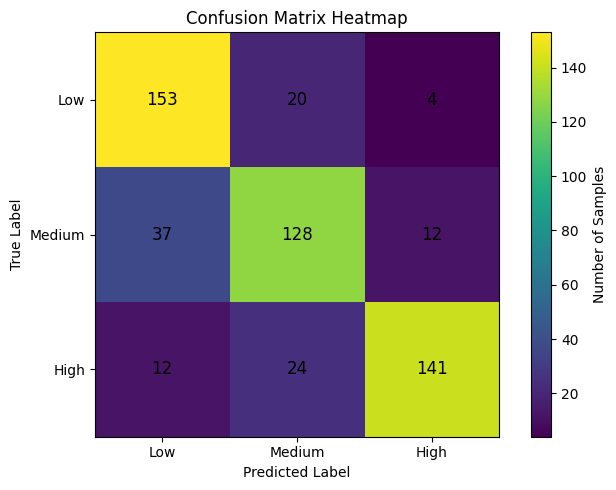

In [17]:
# ====================================================
# 🔥 Confusion Matrix Heatmap
# ====================================================

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

labels = ["Low", "Medium", "High"]

cm = confusion_matrix(true_labels, pred_labels)

plt.figure(figsize=(7, 5))
plt.imshow(cm)

plt.title("Confusion Matrix Heatmap")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(np.arange(len(labels)), labels)
plt.yticks(np.arange(len(labels)), labels)

# كتابة الأرقام جوه المربعات
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j, i, cm[i, j],
            ha="center",
            va="center",
            fontsize=12
        )

plt.colorbar(label="Number of Samples")
plt.tight_layout()
plt.show()

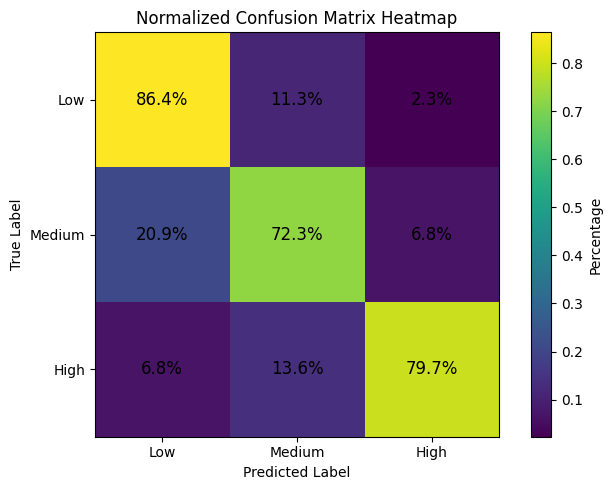

In [18]:
# ====================================================
# 🔥 Normalized Confusion Matrix Heatmap
# ====================================================

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

labels = ["Low", "Medium", "High"]

cm = confusion_matrix(true_labels, pred_labels)
cm_percent = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(7, 5))
plt.imshow(cm_percent)

plt.title("Normalized Confusion Matrix Heatmap")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(np.arange(len(labels)), labels)
plt.yticks(np.arange(len(labels)), labels)

for i in range(cm_percent.shape[0]):
    for j in range(cm_percent.shape[1]):
        plt.text(
            j, i,
            f"{cm_percent[i, j]*100:.1f}%",
            ha="center",
            va="center",
            fontsize=12
        )

plt.colorbar(label="Percentage")
plt.tight_layout()
plt.show()

## 💾 الخطوة 6 — حفظ النموذج

In [19]:
# ====================================================
# 💾 Save Final Trained Safety Model
# ====================================================

import os
import json

SAVE_PATH = "rxchat_safety_model_final_fixed"

os.makedirs(SAVE_PATH, exist_ok=True)

# حفظ أفضل موديل اتدرّب
trainer.model.save_pretrained(SAVE_PATH)

# حفظ tokenizer
tokenizer.save_pretrained(SAVE_PATH)

# حفظ ترتيب الليبلز
label_info = {
    "label2id": label2id,
    "id2label": id2label
}

with open(os.path.join(SAVE_PATH, "label_mapping.json"), "w", encoding="utf-8") as f:
    json.dump(label_info, f, ensure_ascii=False, indent=4)

print("✅ Model saved successfully")
print("📁 Save path:", os.path.abspath(SAVE_PATH))
print("📌 Files inside folder:")
print(os.listdir(SAVE_PATH))

✅ Model saved successfully
📁 Save path: c:\my\Projectes\DeepLearning\MedChat\new_data\pers_two\rxchat_safety_model_final_fixed
📌 Files inside folder:
['config.json', 'label_mapping.json', 'model.safetensors', 'special_tokens_map.json', 'tokenizer.json', 'tokenizer_config.json', 'vocab.txt']


## 🧪 اختبار النموذج — جرب بنفسك

In [ ]:
df.head()

,id,drug_name,generic_name,drug_class,text,patient_context,risk_level,risk_flags,explanation,source,dialect_label,severity_score,doctor_referral,label_id
0,SYN000001,بنادول,Paracetamol,analgesic,"""دكتور، أنا خدت بنادول إكسترا ٣ حبات ورا بعض ع...","{""age"":30,""weight"":80,""conditions"":[],""current...",Low,[],"""سؤال عادي عن الجرعة القصوى المسموحة، بدون أعر...",patient_info_leaflet,egyptian_arabic,0.15,false,0
1,SYN000002,بروفين,Ibuprofen,nsaid,"""عندي آلام دوره، بنتي عمرها ١٤ سنه، بتاخد بروف...","{""age"":14,""weight"":50,""conditions"":[""dysmenorr...",Medium,[monitoring_required],"""ألم معدة من الأعراض الجانبية الشائعة للبروفين...",patient_info_leaflet,egyptian_arabic,0.42,false,1
2,SYN000003,كونكور,Bisoprolol,beta blocker,"""والدي لسه باديء كونكور من ٣ ايام، النهارده ضغ...","{""age"":70,""weight"":85,""conditions"":[""hypertens...",Medium,[monitoring_required],"""انخفاض الضغط والدوخة من الأعراض المتوقعة لبدا...",medical_guidelines,egyptian_arabic,0.35,false,1
3,SYN000004,كريستور,Rosuvastatin,statin,"""أنا خدت كريستور ٤٠ مجم امبارح بالليل، وحاسس ب...","{""age"":55,""weight"":90,""conditions"":[""hyperlipi...",Medium,[monitoring_required],"""ألم في عضلة الساق من الأعراض الجانبية للستاتي...",patient_info_leaflet,egyptian_arabic,0.45,false,1
4,SYN000005,زاناكس,Alprazolam,benzodiazepine,"""والدتي عندها ٧٥ سنه، بتاخد ربع حبة زاناكس ٠.٢...","{""age"":75,""weight"":65,""conditions"":[""anxiety"",...",Medium,[monitoring_required],"""كبار السن حساسين جداً للبنزوديازيبينات، حتى ا...",medical_guidelines,egyptian_arabic,0.52,false,1


In [20]:
print(df['risk_level'].value_counts())

risk_level
High      885
Low       675
Medium    614
Name: count, dtype: int64


## 🚀 الخطوة 7 — FastAPI Endpoint
**الكود ده هتشغله على جهازك أو على Render — مش في Colab**

In [21]:
# ====================================================
# 🧪 Test Final Safety Model with Examples
# ====================================================

import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForSequenceClassification

MODEL_PATH = "rxchat_safety_model_final_fixed"

tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH)

device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)
model.eval()

id2label = {
    0: "Low",
    1: "Medium",
    2: "High"
}

def predict_safety(text):
    encoding = tokenizer(
        text,
        max_length=128,
        padding="max_length",
        truncation=True,
        return_tensors="pt"
    )

    encoding = {k: v.to(device) for k, v in encoding.items()}

    with torch.no_grad():
        outputs = model(**encoding)
        probs = F.softmax(outputs.logits, dim=-1)[0]

    pred_id = torch.argmax(probs).item()

    return {
        "prediction": id2label[pred_id],
        "confidence": round(probs[pred_id].item(), 3),
        "probabilities": {
            "Low": round(probs[0].item(), 3),
            "Medium": round(probs[1].item(), 3),
            "High": round(probs[2].item(), 3)
        }
    }


test_examples = [
    # =========================
    # Low Risk Examples
    # =========================
    {
        "expected": "Low",
        "text": "أنا عندي 25 سنة ومفيش أمراض مزمنة، بانادول بيسبب نعاس؟"
    },
    {
        "expected": "Low",
        "text": "ممكن أعرف باراسيتامول بيتاخد قبل الأكل ولا بعد الأكل؟"
    },
    {
        "expected": "Low",
        "text": "أنا شاب سليم ومش باخد أي أدوية، هل فيتامين سي ينفع يتاخد يوميًا؟"
    },

    # =========================
    # Medium Risk Examples
    # =========================
    {
        "expected": "Medium",
        "text": "والدي عنده 65 سنة وعنده ضغط وبياخد كونكور، وحاسس بدوخة بعد الدواء."
    },
    {
        "expected": "Medium",
        "text": "أنا عندي سكر وباخد ميتفورمين، ينفع آخد دواء برد؟"
    },
    {
        "expected": "Medium",
        "text": "أنا حامل في الشهر الرابع وعندي صداع، ينفع آخد مسكن؟"
    },

    # =========================
    # High Risk Examples
    # =========================
    {
        "expected": "High",
        "text": "أنا عندي قصور كلوي شديد ومحتاج آخد فولتارين لوجع الظهر."
    },
    {
        "expected": "High",
        "text": "أنا باخد وارفارين، ينفع آخد أسبرين معاه؟"
    },
    {
        "expected": "High",
        "text": "طفل عنده سنتين أخد جرعة زيادة من الباراسيتامول ومش عارفين نعمل إيه."
    },
    {
        "expected": "High",
        "text": "بعد ما أخدت الدواء حصل عندي ضيق تنفس وتورم في الوش."
    },
    {
        "expected": "High",
        "text": "أنا عندي ألم شديد في الصدر ودوخة بعد ما أخدت الدواء."
    }
]


correct = 0

for i, example in enumerate(test_examples, 1):
    result = predict_safety(example["text"])

    is_correct = result["prediction"] == example["expected"]
    if is_correct:
        correct += 1

    print("=" * 90)
    print(f"Test {i}")
    print("Text:", example["text"])
    print("Expected:", example["expected"])
    print("Predicted:", result["prediction"])
    print("Correct:", "✅" if is_correct else "❌")
    print("Confidence:", result["confidence"])
    print("Probabilities:", result["probabilities"])

print("=" * 90)
print(f"Final Test Accuracy on examples: {correct}/{len(test_examples)}")

Test 1
Text: أنا عندي 25 سنة ومفيش أمراض مزمنة، بانادول بيسبب نعاس؟
Expected: Low
Predicted: Low
Correct: ✅
Confidence: 0.978
Probabilities: {'Low': 0.978, 'Medium': 0.015, 'High': 0.007}
Test 2
Text: ممكن أعرف باراسيتامول بيتاخد قبل الأكل ولا بعد الأكل؟
Expected: Low
Predicted: Low
Correct: ✅
Confidence: 0.973
Probabilities: {'Low': 0.973, 'Medium': 0.022, 'High': 0.005}
Test 3
Text: أنا شاب سليم ومش باخد أي أدوية، هل فيتامين سي ينفع يتاخد يوميًا؟
Expected: Low
Predicted: Low
Correct: ✅
Confidence: 0.977
Probabilities: {'Low': 0.977, 'Medium': 0.018, 'High': 0.006}
Test 4
Text: والدي عنده 65 سنة وعنده ضغط وبياخد كونكور، وحاسس بدوخة بعد الدواء.
Expected: Medium
Predicted: Low
Correct: ❌
Confidence: 0.586
Probabilities: {'Low': 0.586, 'Medium': 0.296, 'High': 0.118}
Test 5
Text: أنا عندي سكر وباخد ميتفورمين، ينفع آخد دواء برد؟
Expected: Medium
Predicted: Low
Correct: ❌
Confidence: 0.913
Probabilities: {'Low': 0.913, 'Medium': 0.069, 'High': 0.018}
Test 6
Text: أنا حامل في الشهر الرابع و

In [27]:
# ====================================================
# Flask API for RxChat Safety Classification Model
# ====================================================

import os
import torch
import torch.nn.functional as F
from flask import Flask, request, jsonify
from flask_cors import CORS
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# ----------------------------------------------------
# Config
# ----------------------------------------------------

MODEL_PATH = "rxchat_safety_model_final_fixed"
MAX_LEN = 128

id2label = {
    0: "Low",
    1: "Medium",
    2: "High"
}

# ----------------------------------------------------
# Load Model
# ----------------------------------------------------

print("⏳ Loading Safety Model...")

device = "cuda" if torch.cuda.is_available() else "cpu"

tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH)

model = model.to(device)
model.eval()

print("✅ Model loaded successfully")
print("Device:", device)

# ----------------------------------------------------
# Flask App
# ----------------------------------------------------

app = Flask(__name__)
CORS(app)

# ----------------------------------------------------
# Prediction Function
# ----------------------------------------------------

def predict_safety(text: str):
    if not text or not isinstance(text, str):
        raise ValueError("Text must be a non-empty string")

    encoding = tokenizer(
        text,
        max_length=MAX_LEN,
        padding="max_length",
        truncation=True,
        return_tensors="pt"
    )

    encoding = {k: v.to(device) for k, v in encoding.items()}

    with torch.no_grad():
        outputs = model(**encoding)
        probs = F.softmax(outputs.logits, dim=-1)[0]

    pred_id = torch.argmax(probs).item()
    risk_level = id2label[pred_id]
    confidence = probs[pred_id].item()

    return {
        "risk_level": risk_level,
        "confidence": round(confidence, 4),
        "probabilities": {
            "Low": round(probs[0].item(), 4),
            "Medium": round(probs[1].item(), 4),
            "High": round(probs[2].item(), 4)
        }
    }

# ----------------------------------------------------
# Routes
# ----------------------------------------------------

@app.route("/", methods=["GET"])
def home():
    return jsonify({
        "message": "RxChat Safety Model API is running",
        "endpoints": {
            "health": "/health",
            "predict": "/predict"
        }
    })


@app.route("/health", methods=["GET"])
def health():
    return jsonify({
        "status": "ok",
        "model_path": MODEL_PATH,
        "device": device
    })

@app.route("/predict", methods=["GET", "POST"])
def predict():
    try:
        # لو فتحت من المتصفح عادي GET
        if request.method == "GET":
            text = request.args.get("text", "")

            # لو مفيش text اعرض صفحة بسيطة
            if text.strip() == "":
                return """
                <!DOCTYPE html>
                <html lang="ar" dir="rtl">
                <head>
                    <meta charset="UTF-8">
                    <title>RxChat Safety Classifier</title>
                    <style>
                        body {
                            font-family: Arial, sans-serif;
                            background: #f4f7f8;
                            padding: 40px;
                            direction: rtl;
                        }
                        .container {
                            max-width: 700px;
                            margin: auto;
                            background: white;
                            padding: 25px;
                            border-radius: 12px;
                            box-shadow: 0 0 15px rgba(0,0,0,0.1);
                        }
                        textarea {
                            width: 100%;
                            height: 130px;
                            font-size: 18px;
                            padding: 10px;
                            border-radius: 8px;
                            border: 1px solid #ccc;
                        }
                        button {
                            margin-top: 15px;
                            background: #0d6efd;
                            color: white;
                            border: none;
                            padding: 12px 25px;
                            border-radius: 8px;
                            font-size: 18px;
                            cursor: pointer;
                        }
                        button:hover {
                            background: #084298;
                        }
                    </style>
                </head>
                <body>
                    <div class="container">
                        <h2>💊 RxChat Safety Classifier</h2>
                        <p>اكتب سؤال المريض واضغط Predict</p>

                        <form method="GET" action="/predict">
                            <textarea name="text" placeholder="مثال: أنا عندي قصور كلوي شديد ومحتاج آخد فولتارين لوجع الظهر"></textarea>
                            <br>
                            <button type="submit">Predict</button>
                        </form>
                    </div>
                </body>
                </html>
                """

            result = predict_safety(text)

            return f"""
            <!DOCTYPE html>
            <html lang="ar" dir="rtl">
            <head>
                <meta charset="UTF-8">
                <title>Prediction Result</title>
                <style>
                    body {{
                        font-family: Arial, sans-serif;
                        background: #f4f7f8;
                        padding: 40px;
                        direction: rtl;
                    }}
                    .container {{
                        max-width: 700px;
                        margin: auto;
                        background: white;
                        padding: 25px;
                        border-radius: 12px;
                        box-shadow: 0 0 15px rgba(0,0,0,0.1);
                    }}
                    .risk {{
                        font-size: 28px;
                        font-weight: bold;
                        color: #0d6efd;
                    }}
                    pre {{
                        background: #eee;
                        padding: 15px;
                        border-radius: 8px;
                        direction: ltr;
                        text-align: left;
                    }}
                    a {{
                        display: inline-block;
                        margin-top: 20px;
                        text-decoration: none;
                        color: white;
                        background: #0d6efd;
                        padding: 10px 20px;
                        border-radius: 8px;
                    }}
                </style>
            </head>
            <body>
                <div class="container">
                    <h2>💊 RxChat Safety Prediction</h2>

                    <p><b>النص:</b></p>
                    <p>{text}</p>

                    <p><b>التصنيف:</b></p>
                    <p class="risk">{result["risk_level"]}</p>

                    <p><b>Confidence:</b> {result["confidence"]}</p>

                    <p><b>Probabilities:</b></p>
                    <pre>{result["probabilities"]}</pre>

                    <a href="/predict">جرب سؤال تاني</a>
                </div>
            </body>
            </html>
            """

        # لو POST من Postman أو أي frontend
        data = request.get_json()

        if data is None:
            return jsonify({
                "error": "Invalid JSON body"
            }), 400

        text = data.get("text", "")
        result = predict_safety(text)

        return jsonify({
            "input_text": text,
            "prediction": result
        })

    except ValueError as e:
        return jsonify({
            "error": str(e)
        }), 400

    except Exception as e:
        return jsonify({
            "error": "Internal server error",
            "details": str(e)
        }), 500
# ----------------------------------------------------
# Run Server
# ----------------------------------------------------
if __name__ == "__main__":
    app.run(
        host="127.0.0.1",
        port=5000,
        debug=False,
        use_reloader=False
    )

⏳ Loading Safety Model...
✅ Model loaded successfully
Device: cpu
 * Serving Flask app '__main__'
 * Debug mode: off


 * Running on http://127.0.0.1:5000
Press CTRL+C to quit
127.0.0.1 - - [13/May/2026 05:37:37] "GET /health HTTP/1.1" 200 -
127.0.0.1 - - [13/May/2026 05:37:39] "GET /health HTTP/1.1" 200 -
127.0.0.1 - - [13/May/2026 05:37:45] "GET /predict HTTP/1.1" 200 -
127.0.0.1 - - [13/May/2026 05:38:08] "GET /predict?text=انا+هاخد+ترامادول+عشان+انتحر%0D%0A HTTP/1.1" 200 -
127.0.0.1 - - [13/May/2026 05:38:14] "GET /predict HTTP/1.1" 200 -
127.0.0.1 - - [13/May/2026 05:38:28] "GET /predict?text=هاخد+بنادول+ععشان+الصداع%0D%0A HTTP/1.1" 200 -
127.0.0.1 - - [13/May/2026 05:38:30] "GET /predict HTTP/1.1" 200 -
127.0.0.1 - - [13/May/2026 05:38:51] "GET /predict?text=أنا+عندي+قصور+كلوي+شديد+ومحتاج+آخد+فولتارين+لوجع+الظهر HTTP/1.1" 200 -
